In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
data = {
    'income':[12,13,14,6,5,4],
    'credit_score':[750,780,800,300,400,460],
    'Status':['YES','YES','YES','NO','NO','NO']
}
df = pd.DataFrame(data)
df.head(3)

,income,credit_score,Status
0,12,750,YES
1,13,780,YES
2,14,800,YES


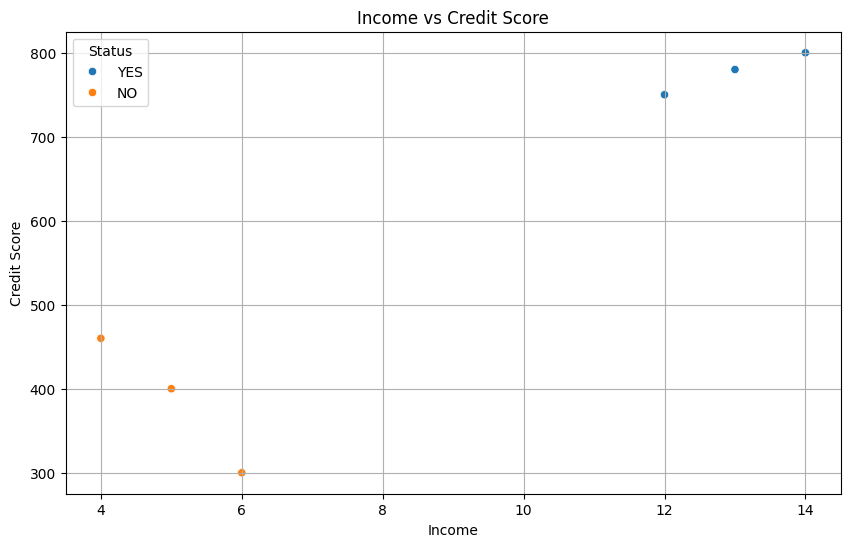

In [3]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='income',y='credit_score',hue='Status',data=df)
plt.title('Income vs Credit Score')
plt.xlabel('Income')
plt.ylabel('Credit Score')
plt.grid()
plt.show()

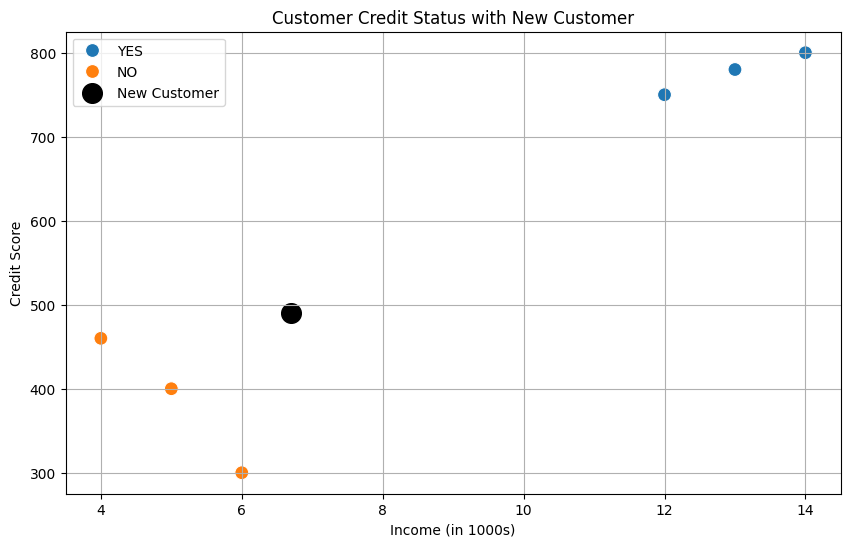

In [4]:
new_customer = [6.7,490]
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='income', y='credit_score', hue='Status', s=100)
plt.scatter(new_customer[0], new_customer[1], color='black', s=200, label='New Customer')
plt.title('Customer Credit Status with New Customer')
plt.xlabel('Income (in 1000s)')
plt.ylabel('Credit Score')
plt.legend()
plt.grid()
plt.show()

In [7]:
p1 =[12,750]
p2 = [9.7,670]

distance = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
distance

np.float64(80.03305567076644)

In [8]:
def euclidean_distance(df, new_customer):
    distances = []
    for index, row in df.iterrows():
        p1 = [row['income'], row['credit_score']]
        p2 = new_customer
        distance = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
        distances.append(distance)
    return distances


new_customer = np.array([6.7, 490])
df['distance'] = euclidean_distance(df, new_customer)


In [10]:
df.sort_values('distance')

,income,credit_score,Status,distance
5,4,460,NO,30.121255
4,5,400,NO,90.016054
3,6,300,NO,190.001289
0,12,750,YES,260.054014
1,13,780,YES,290.068423
2,14,800,YES,310.085940


In [11]:
# Features (X): Each row is a customer vector [income, credit_score]
X = np.array([
    [50, 650], [85, 780], [40, 580], [95, 820], [35, 590],
    [65, 710], [75, 750], [45, 610], [105, 850], [60, 690]
])

# 0: Denied, 1: Approved
y = np.array([0, 1, 0, 1, 0, 1, 1, 0, 1, 0])


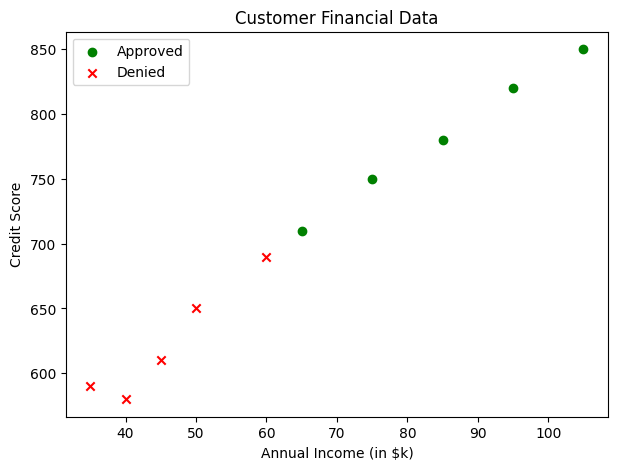

In [12]:
approved = X[y == 1]
denied = X[y == 0]

plt.figure(figsize=(7, 5))
plt.scatter(approved[:, 0], approved[:, 1], c='green', marker='o', label='Approved')
plt.scatter(denied[:, 0], denied[:, 1], c='red', marker='x', label='Denied')

plt.title('Customer Financial Data')
plt.xlabel('Annual Income (in $k)')
plt.ylabel('Credit Score')
plt.legend()
# plt.grid(True)
plt.show()

In [14]:
customer_A = X[0]  # [50, 650], Denied
customer_C = X[2]

In [17]:
w1 = -0.15
w2 =0.025
w0 = 5

# y = w0 + w1 * customer_A[0] + w2 * customer_A[1]

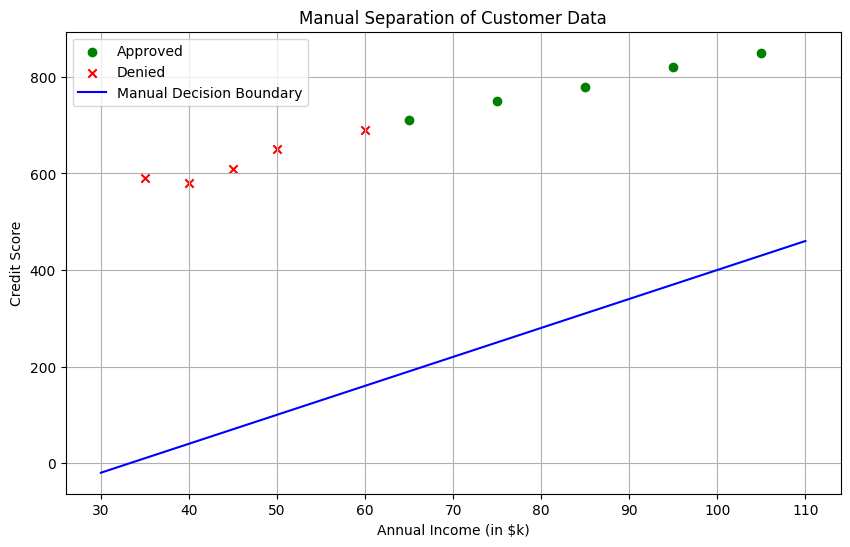

In [18]:
# Plot the original data again
plt.figure(figsize=(10, 6))
plt.scatter(approved[:, 0], approved[:, 1], c='green', marker='o', label='Approved')
plt.scatter(denied[:, 0], denied[:, 1], c='red', marker='x', label='Denied')


income_vals = np.array([X[:, 0].min() - 5, X[:, 0].max() + 5])

score_vals = (-w1 * income_vals - w0) / w2


plt.plot(income_vals, score_vals, 'b-', label='Manual Decision Boundary')
plt.title('Manual Separation of Customer Data')
plt.xlabel('Annual Income (in $k)')
plt.ylabel('Credit Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
W = np.array([w1, w2])
X_new = np.array([90, 760]) 

# Perform the dot product calculation
score = np.dot(W, X_new) + w0

print(f"Weight Vector W: {W}")
print(f"New Applicant X_new: {X_new}")
print(f"Bias w0: {w0}")
print("--- Calculation ---")
print(f"Score (W • X + w0) = {score:.2f}")

if score > 0:
    print("Prediction: Approved ✅")
else:
    print("Prediction: Denied ❌")